Project Phase II: Applied Data Engineering and Machine Learning
--------------------------------------------------------------------------------------------------------------

In [1]:
import pandas as pd

# Load the raw dataset and create a deep copy for further processing
df = pd.read_csv("../data/student-course-completion-prediction-dataset-trimmed.csv")
df_copy = df.copy(deep=True)

In [2]:
# Load data from the ETL database and display the first few rows of the cleaned data.

import sqlite3
import pandas as pd

with sqlite3.connect("..\\data\\etl.db") as conn:
    df_etl_clean = pd.read_sql_query("SELECT * FROM clean", conn)

print("Loaded cleaned data.")
print("Shape:", df_etl_clean.shape)

df_etl_clean.head()

Loaded cleaned data.
Shape: (30000, 41)


,Student_ID,Name,Gender,Age,Education_Level,Employment_Status,City,Device_Type,Internet_Connection_Quality,Course_ID,...,Payment_Mode,Fee_Paid,Discount_Used,Payment_Amount,App_Usage_Percentage,Reminder_Emails_Clicked,Support_Tickets_Raised,Satisfaction_Rating,Completed,Completed_Status
0,STU100000,Vihaan Patel,Male,19,Diploma,Student,Indore,Laptop,Medium,C102,...,Scholarship,No,No,1740,49,3,4,3.5,Completed,1
1,STU100001,Arjun Nair,Female,17,Bachelor,Student,Delhi,Laptop,Low,C106,...,Credit Card,Yes,No,6147,86,0,0,4.5,Not Completed,0
2,STU100002,Aditya Bhardwaj,Female,34,Master,Student,Chennai,Mobile,Medium,C101,...,NetBanking,Yes,No,4280,85,1,0,5.0,Completed,1
3,STU100003,Krishna Singh,Female,29,Diploma,Employed,Surat,Mobile,High,C105,...,UPI,Yes,No,3812,42,2,3,3.8,Completed,1
4,STU100004,Krishna Nair,Female,19,Master,Self-Employed,Lucknow,Laptop,Medium,C106,...,Debit Card,Yes,Yes,5486,91,3,0,4.0,Completed,1


TASK 2: Original LCS System on raw Dataset

In [3]:
for col in df_etl_clean.columns:
    print(
        f"{col}: {df_etl_clean[col].dtype}, unique: {df_etl_clean[col].nunique(dropna=True)}"
    )

Student_ID: str, unique: 30000
Name: str, unique: 300
Gender: str, unique: 3
Age: int64, unique: 33
Education_Level: str, unique: 5
Employment_Status: str, unique: 4
City: str, unique: 15
Device_Type: str, unique: 3
Internet_Connection_Quality: str, unique: 3
Course_ID: str, unique: 8
Course_Name: str, unique: 8
Category: str, unique: 5
Course_Level: str, unique: 3
Course_Duration_Days: int64, unique: 8
Instructor_Rating: float64, unique: 7
Login_Frequency: int64, unique: 16
Average_Session_Duration_Min: int64, unique: 72
Video_Completion_Rate: float64, unique: 929
Discussion_Participation: int64, unique: 13
Time_Spent_Hours: float64, unique: 209
Days_Since_Last_Login: int64, unique: 71
Notifications_Checked: int64, unique: 19
Peer_Interaction_Score: float64, unique: 101
Assignments_Submitted: int64, unique: 11
Assignments_Missed: int64, unique: 11
Quiz_Attempts: int64, unique: 16
Quiz_Score_Avg: float64, unique: 668
Project_Grade: float64, unique: 811
Progress_Percentage: float64, uni

In [4]:
# Copy the cleaned dataset for eLCS preparation
elcs_df = df_etl_clean.copy()

# Remove identifier, free-text, and target-derived helper columns
# Completed_Status must be removed because it is derived from the target
# and would cause target leakage
elcs_df = elcs_df.drop(
    columns=["Student_ID", "Name", "Completed_Status"], errors="ignore"
)

# Convert Enrollment_Date into numeric date components
if "Enrollment_Date" in elcs_df.columns:
    elcs_df["Enrollment_Date"] = pd.to_datetime(elcs_df["Enrollment_Date"])

    elcs_df["Enrollment_Year"] = elcs_df["Enrollment_Date"].dt.year
    elcs_df["Enrollment_Month"] = elcs_df["Enrollment_Date"].dt.month
    elcs_df["Enrollment_Day"] = elcs_df["Enrollment_Date"].dt.day

    elcs_df = elcs_df.drop(columns=["Enrollment_Date"])

# Separate predictors from target
y = elcs_df["Completed"].copy()
X = elcs_df.drop(columns=["Completed"]).copy()

# Find categorical predictor columns
categorical_cols = X.select_dtypes(include=["object", "string", "category"]).columns

# Convert categorical predictors into numeric category codes
for col in categorical_cols:
    X[col] = X[col].astype("category").cat.codes

# Convert target to numeric
# Completed = 1
# Not Completed = 0
y = y.map({"Completed": 1, "Not Completed": 0})

# Check that all predictors are numeric
non_numeric_cols = X.select_dtypes(exclude="number").columns.tolist()

print("Non-numeric predictor columns:")
print(non_numeric_cols)

print("\nMissing target values after conversion:")
print(y.isna().sum())

# Convert to NumPy arrays for eLCS
dataFeatures = X.to_numpy()
dataPhenotypes = y.to_numpy()

print("\nFeature shape:", dataFeatures.shape)
print("Target shape:", dataPhenotypes.shape)

print("\nFeature dtype:", dataFeatures.dtype)
print("Target dtype:", dataPhenotypes.dtype)

print("\nTarget values:", set(dataPhenotypes))

Non-numeric predictor columns:
[]

Missing target values after conversion:
0

Feature shape: (30000, 39)
Target shape: (30000,)

Feature dtype: float64
Target dtype: int64

Target values: {np.int64(0), np.int64(1)}


In [5]:
from skeLCS import StringEnumerator, eLCS

print("eLCS import successful")

eLCS import successful


In [6]:
# Start from the raw working dataset
baseline_df = df_copy.copy()

# Remove columns that should not be predictors
baseline_df = baseline_df.drop(
    columns=[
        "Student_ID",  # identifier only
        "Name",  # free-text identifier
        "Completed_Status",
    ],
    errors="ignore",
)

# Convert Enrollment_Date only because eLCS needs numeric input
if "Enrollment_Date" in baseline_df.columns:
    baseline_df["Enrollment_Date"] = pd.to_datetime(
        baseline_df["Enrollment_Date"], dayfirst=True
    )

    baseline_df["Enrollment_Year"] = baseline_df["Enrollment_Date"].dt.year
    baseline_df["Enrollment_Month"] = baseline_df["Enrollment_Date"].dt.month
    baseline_df["Enrollment_Day"] = baseline_df["Enrollment_Date"].dt.day

    baseline_df = baseline_df.drop(columns=["Enrollment_Date"])

# Separate target from predictors
y_baseline = baseline_df["Completed"].copy()
X_baseline = baseline_df.drop(columns=["Completed"]).copy()

# Convert categorical predictors to numeric codes
categorical_cols = X_baseline.select_dtypes(
    include=["object", "string", "category"]
).columns

for col in categorical_cols:
    X_baseline[col] = X_baseline[col].astype("category").cat.codes

# Convert target to binary numeric values
y_baseline = y_baseline.map({"Completed": 1, "Not Completed": 0})

# Verify that the minimally processed baseline is ready
print("Baseline feature shape:", X_baseline.shape)
print("Baseline target shape:", y_baseline.shape)

print("\nNon-numeric predictor columns:")
print(X_baseline.select_dtypes(exclude="number").columns.tolist())

print("\nMissing target values:")
print(y_baseline.isna().sum())

print("\nTarget classes:")
print(set(y_baseline))

Baseline feature shape: (30000, 39)
Baseline target shape: (30000,)

Non-numeric predictor columns:
[]

Missing target values:
0

Target classes:
{0, 1}


In [7]:
from sklearn.model_selection import train_test_split

# Split the minimally processed baseline data
X_train, X_test, y_train, y_test = train_test_split(
    X_baseline, y_baseline, test_size=0.20, random_state=42, stratify=y_baseline
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training features: (24000, 39)
Testing features: (6000, 39)
Training target: (24000,)
Testing target: (6000,)

Training class distribution:
Completed
0    12166
1    11834
Name: count, dtype: int64

Testing class distribution:
Completed
0    3042
1    2958
Name: count, dtype: int64


In [8]:
from skeLCS import eLCS

# Create the original eLCS baseline model
baseline_elcs_model = eLCS(learning_iterations=5000)

print("Baseline eLCS model created.")

Baseline eLCS model created.


In [13]:
# Train the original eLCS model
baseline_elcs_model.fit(X_train.values, y_train.values)

print("eLCS training complete")
print("Training accuracy:", baseline_elcs_model.score(X_train.values, y_train.values))
print("Test accuracy:", baseline_elcs_model.score(X_test.values, y_test.values))

eLCS training complete
Training accuracy: 0.5423515766669905
Test accuracy: 0.5232392215540913


In [ ]:
# Evaluate the original eLCS model using cross-validation
from sklearn.model_selection import cross_val_score
import numpy as np

# Shuffle Data (useful for cross validation)
formatted = np.insert(dataFeatures, dataFeatures.shape[1], dataPhenotypes, 1)
np.random.shuffle(formatted)
dataFeatures = np.delete(formatted, -1, axis=1)
dataPhenotypes = formatted[:, -1]

print(
    "Cross-validation accuracy:",
    np.mean(cross_val_score(baseline_elcs_model, X_train.values, y_train.values, cv=3)),
)

Cross-validation accuracy: 0.5218496149447369


In [10]:
# Display the baseline eLCS parameters
baseline_params = baseline_elcs_model.get_params()

print("Baseline eLCS parameters:")
for key, value in baseline_params.items():
    print(f"{key}: {value}")

Baseline eLCS parameters:
N: 1000
acc_sub: 0.99
beta: 0.2
chi: 0.8
delta: 0.1
discrete_attribute_limit: 10
do_GA_subsumption: True
do_correct_set_subsumption: False
fitness_reduction: 0.1
init_fit: 0.01
learning_iterations: 5000
match_for_missingness: False
mu: 0.04
nu: 5
p_spec: 0.5
random_state: None
reboot_filename: None
selection_method: tournament
specified_attributes: []
theta_GA: 25
theta_del: 20
theta_sel: 0.5
theta_sub: 20
track_accuracy_while_fit: False


Original eLCS Baseline Performance
----------------------------------
Accuracy:          0.5217
Precision:         0.5120
Recall:            0.6356
F1 Score:          0.5671
Balanced Accuracy: 0.5232

Confusion Matrix:
[[1250 1792]
 [1078 1880]]
Roc/PRC curves


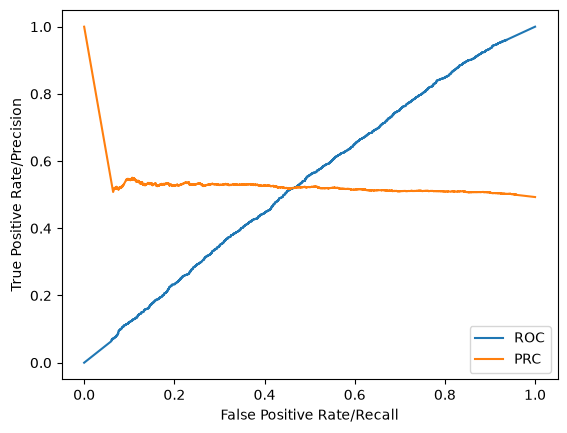

PRC AUC:0.5342468447661555
ROC AUC:0.539550585248042
Final Training Accuracy: 0.5423515766669905
Final Instance Coverage: 0.9972083333333334
Final Attribute Specificity List: [391, 367, 401, 394, 341, 405, 400, 336, 341, 385, 363, 342, 360, 451, 386, 408, 437, 380, 456, 480, 385, 386, 376, 439, 394, 424, 415, 447, 329, 419, 398, 370, 411, 396, 374, 413, 331, 375, 383]
Final Attribute Accuracy List: [353.0709125297358, 328.51100148057185, 356.94823800546965, 346.66604085386047, 322.6536846882048, 364.65399715850157, 360.0252095943274, 306.4421421361924, 312.1481684981683, 332.3341466196343, 332.3681258155331, 318.79935538317886, 340.00797397047404, 389.9401884911413, 346.25274956736627, 349.8679537228064, 371.86968821082576, 334.35144499220564, 378.3249337540458, 413.4709696202766, 347.1439999411581, 341.3955463902394, 340.97009763878464, 369.39183325604614, 355.20966938809687, 369.81332295594484, 370.6178076825136, 387.5402150910664, 311.2109166196123, 368.242132906632, 355.64548890913

In [ ]:
import matplotlib.pyplot as plt

from skeLCS import eLCS
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
)

# Make predictions on the test dataset
y_pred_baseline = baseline_elcs_model.predict(X_test.values)
probabilities = baseline_elcs_model.predict_proba(X_test.values)

# Calculate baseline performance metrics
accuracy = accuracy_score(y_test, y_pred_baseline)
precision = precision_score(y_test, y_pred_baseline)
recall = recall_score(y_test, y_pred_baseline)
f1 = f1_score(y_test, y_pred_baseline)
balanced_acc = balanced_accuracy_score(y_test, y_pred_baseline)

# Receiver Operating Characteristic curve
fpr, tpr, thresholds_roc = roc_curve(y_test, probabilities[:, 1])

# Precision-Recall curve
precision_curve, recall_curve, thresholds_prc = precision_recall_curve(
    y_test, probabilities[:, 1]
)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_baseline)

print("Original eLCS Baseline Performance")
print("----------------------------------")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Precision:         {precision:.4f}")
print(f"Recall:            {recall:.4f}")
print(f"F1 Score:          {f1:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("ROC/PRC curves")

plt.plot(fpr, tpr, label="ROC")
plt.plot(recall_curve, precision_curve, label="PRC")
plt.xlabel("False Positive Rate/Recall")
plt.ylabel("True Positive Rate/Precision")
plt.legend()
plt.show()

print("PRC AUC:" + str(auc(recall_curve, precision_curve)))
print("ROC AUC:" + str(auc(fpr, tpr)))

print("Final Training Accuracy: " + str(baseline_elcs_model.get_final_accuracy()))
print(
    "Final Instance Coverage: " + str(baseline_elcs_model.get_final_instance_coverage())
)
print(
    "Final Attribute Specificity List: "
    + str(baseline_elcs_model.get_final_attribute_specificity_list())
)
print(
    "Final Attribute Accuracy List: "
    + str(baseline_elcs_model.get_final_attribute_accuracy_list())
)

In [ ]:
print(X.columns.tolist())
print("\nNumber of features:", X.shape[1])

Minimal processing: 
-Student_ID removed because it is only an identifier and not a meaningful predictor.
-Name removed because it is free-text/identifier information.
-Completed_Status removed because it was derived from the target and would cause target leakage.
-Enrollment_Date converted into numeric year/month/day values because eLCS requires numeric inputs.
-Categorical predictors such as Gender, City, Course_Level, etc. converted into numeric category codes so eLCS could process them.
-Completed converted from Completed / Not Completed into 1 / 0 because the model needs numeric class labels.
-No feature engineering, scaling, tuning, balancing, or optimisation was applied at this stage, so this remains the raw/minimally processed baseline.

Task 3: Data Preprocessing and Feature Engineering

In [ ]:
# TASK 3 - Step 1: Data Quality Checks

task3_df = df_etl_clean.copy(deep=True)

print("Dataset shape:")
print(task3_df.shape)

# 1. Missing values
print("\nMissing values:")
print(task3_df.isnull().sum()[task3_df.isnull().sum() > 0])

# 2. Duplicate rows
duplicate_rows = task3_df.duplicated().sum()
print("\nDuplicate rows:")
print(duplicate_rows)

# 3. Duplicate Student IDs
if "Student_ID" in task3_df.columns:
    duplicate_ids = task3_df["Student_ID"].duplicated().sum()
    print("\nDuplicate Student_ID values:")
    print(duplicate_ids)

# 4. Data types
print("\nData types:")
print(task3_df.dtypes)

# 5. Check categorical consistency
categorical_cols = task3_df.select_dtypes(
    include=["object", "string", "category"]
).columns

print("\nCategorical unique values:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(task3_df[col].value_counts(dropna=False).head(20))

# 6. Basic numerical validity checks
numeric_cols = task3_df.select_dtypes(include="number").columns

print("\nNumerical ranges:")
for col in numeric_cols:
    print(f"{col}: " f"min={task3_df[col].min()}, " f"max={task3_df[col].max()}")